## Assignment 1 - COMP9414
## By Pulkit Jain - z5708011

In [834]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

print("Imports successful")

Imports successful


In [835]:
from pathlib import Path
import glob

baseDirectory = Path.cwd()

datasetsDirectory = baseDirectory / "datasets"
figuresDirectory = baseDirectory / "figures"
scalersDirectory = baseDirectory / "scalers"
outputsDirectory = baseDirectory / "outputs"
modelsDirectory = baseDirectory / "models"

for folder in [figuresDirectory, scalersDirectory, outputsDirectory, modelsDirectory]:
    folder.mkdir(exist_ok=True)

print("Folders ready.")

Folders ready.


In [836]:
datasetFiles = sorted(glob.glob(str(datasetsDirectory / "daily_solar_*.csv")))

print("Total files:", len(datasetFiles))

dfs = []
for file in datasetFiles:
    df = pd.read_csv(file)
    dfs.append(df)

dfSort = pd.concat(dfs, ignore_index=True)

dfSort["date"] = pd.to_datetime(dfSort["date"])
dfSort = dfSort.sort_values("date")

print("Dataset shape:", dfSort.shape)

dfSort.head()

Total files: 18
Dataset shape: (6575, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


In [837]:
print("Columns:")
print(dfSort.columns)

print("\nDate Range:")
print(dfSort["date"].min(), "to", dfSort["date"].max())

print("\nBad quality:")
print(dfSort["bad_quality"].value_counts())

Columns:
Index(['date', 'solar_t', 'bad_quality'], dtype='str')

Date Range:
1996-01-01 00:00:00 to 2013-12-31 00:00:00

Bad quality:
bad_quality
0    5570
1    1005
Name: count, dtype: int64


In [838]:
rowsTotal = len(dfSort)

rowsBad = (dfSort["bad_quality"] == 1).sum()

dfCleaned = dfSort[dfSort["bad_quality"] == 0].copy()

percentageRemoved = (rowsBad / rowsTotal) * 100

print("Total rows:", rowsTotal)
print("Bad rows removed:", rowsBad)
print("Remaining rows:", len(dfCleaned))
print(f"Percentage removed: {percentageRemoved:.2f}%")

Total rows: 6575
Bad rows removed: 1005
Remaining rows: 5570
Percentage removed: 15.29%


## Part A — Data Preprocessing

- Load and Clean Data
- Fourier Cyclical Encoding
- Rolling Statistics
- Lagged Features
- Target Variables
- Scaling
- Visualisation

In [839]:
dfSort = dfSort.sort_values("date").reset_index(drop=True)
dfCleaned = dfCleaned.sort_values("date").reset_index(drop=True)

print("dfSort shape:", dfSort.shape)
print("dfCleaned shape:", dfCleaned.shape)
dfCleaned.head()

dfSort shape: (6575, 3)
dfCleaned shape: (5570, 3)


,date,solar_t,bad_quality
0,1996-01-01,35.675000,0
1,1996-01-02,105.147917,0
2,1996-01-03,100.647917,0
3,1996-01-04,30.275000,0
4,1996-01-05,92.141962,0


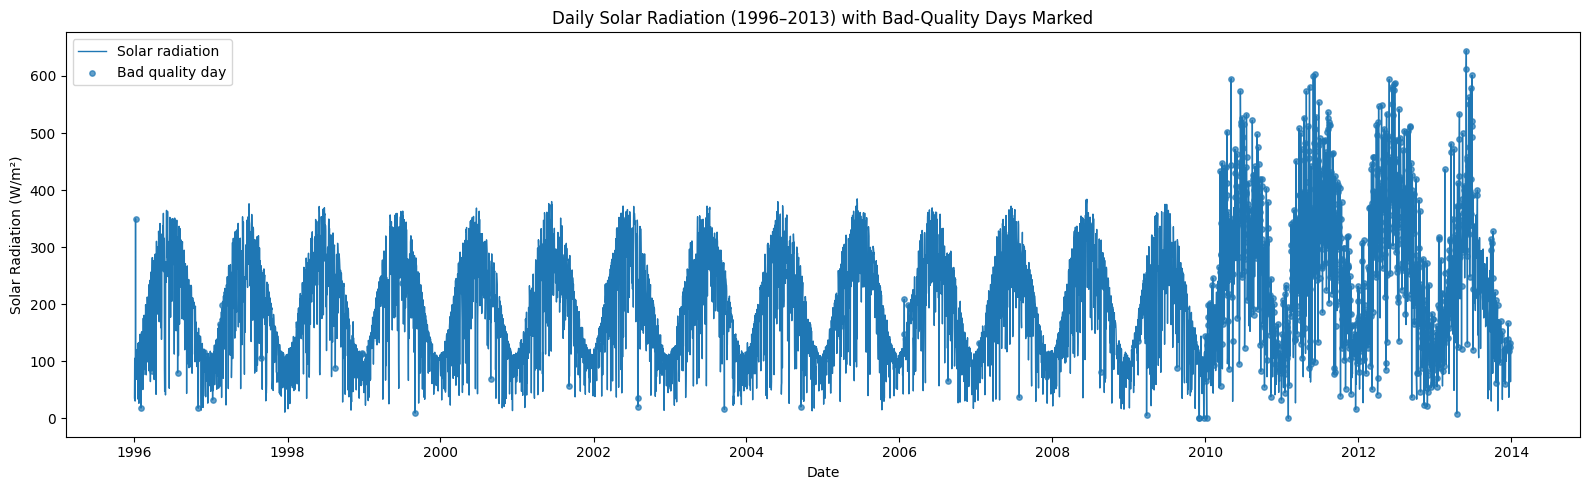

In [840]:
plt.figure(figsize=(16, 5))

plt.plot(
    dfSort["date"],
    dfSort["solar_t"],
    linewidth=1,
    label="Solar radiation"
)

dfBad = dfSort[dfSort["bad_quality"] == 1]

plt.scatter(
    dfBad["date"],
    dfBad["solar_t"],
    s=15,
    alpha=0.7,
    label="Bad quality day"
)

plt.title("Daily Solar Radiation (1996–2013) with Bad-Quality Days Marked")
plt.xlabel("Date")
plt.ylabel("Solar Radiation (W/m²)")
plt.legend()
plt.tight_layout()

plt.savefig(figuresDirectory / "partAtimeseriesbadquality.png", dpi=200)
plt.show()

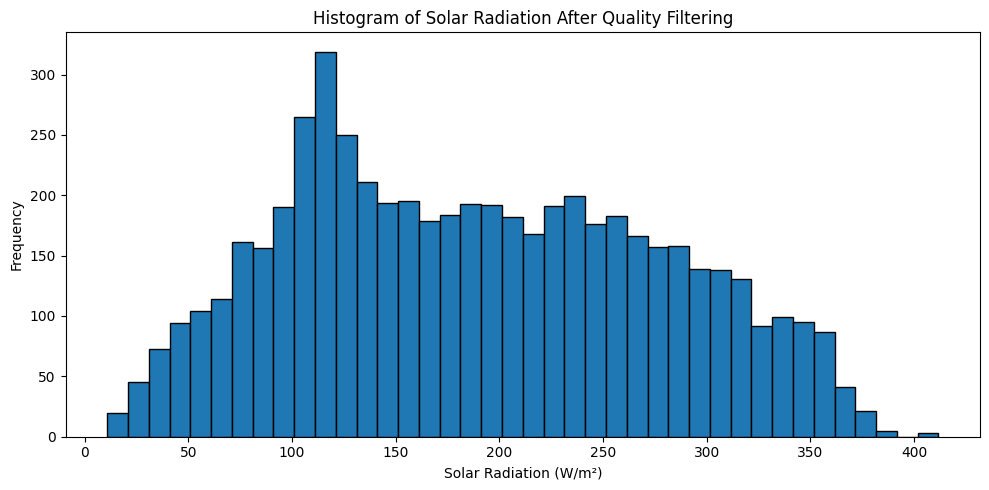

In [841]:
plt.figure(figsize=(10, 5))
plt.hist(dfCleaned["solar_t"], bins=40, edgecolor="black")

plt.title("Histogram of Solar Radiation After Quality Filtering")
plt.xlabel("Solar Radiation (W/m²)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(figuresDirectory / "partAhistogramfiltered.png", dpi=200)
plt.show()

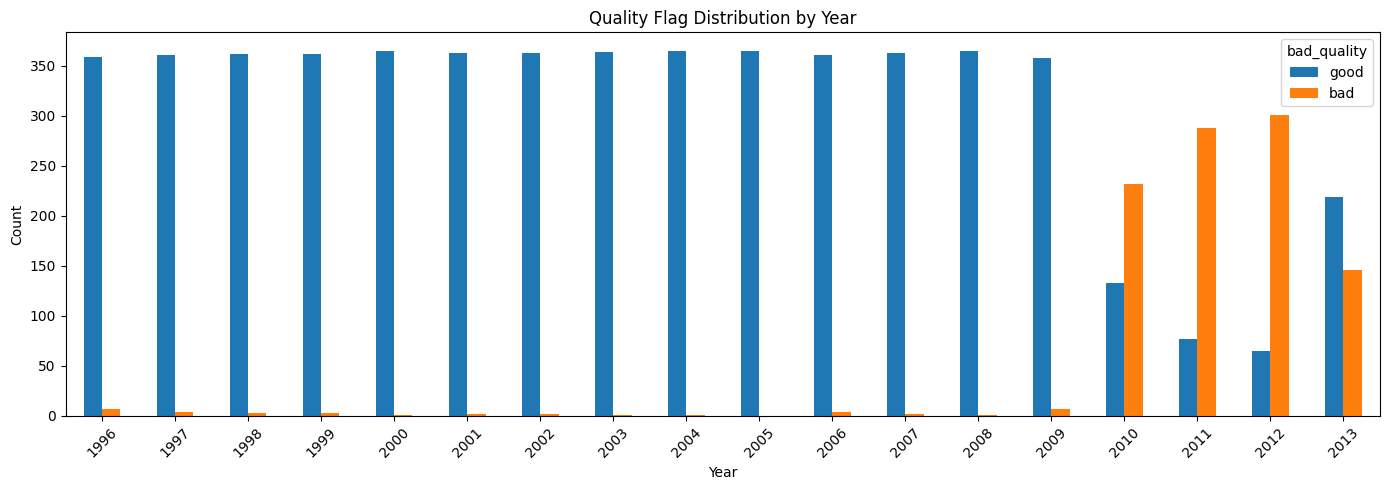

bad_quality,good,bad
year,,
1996,359,7
1997,361,4
1998,362,3
1999,362,3
2000,365,1


In [842]:
dfSort["year"] = dfSort["date"].dt.year

summaryQuality = (
    dfSort.groupby(["year", "bad_quality"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "good", 1: "bad"})
)

summaryQuality.plot(kind="bar", figsize=(14, 5))

plt.title("Quality Flag Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(figuresDirectory / "partAqualitybyyear.png", dpi=200)
plt.show()

summaryQuality.head()

In [843]:
dfPartA = dfCleaned.copy()

dfPartA["day_of_year"] = dfPartA["date"].dt.dayofyear
dfPartA["is_leap_year"] = dfPartA["date"].dt.is_leap_year.astype(int)
dfPartA["days_in_year"] = np.where(dfPartA["is_leap_year"] == 1, 366, 365)

dfPartA["day_sin"] = np.sin(2 * np.pi * dfPartA["day_of_year"] / dfPartA["days_in_year"])
dfPartA["day_cos"] = np.cos(2 * np.pi * dfPartA["day_of_year"] / dfPartA["days_in_year"])

dfPartA[["date", "day_of_year", "days_in_year", "day_sin", "day_cos"]].head()

,date,day_of_year,days_in_year,day_sin,day_cos
0,1996-01-01,1,366,0.017166,0.999853
1,1996-01-02,2,366,0.034328,0.999411
2,1996-01-03,3,366,0.051479,0.998674
3,1996-01-04,4,366,0.068615,0.997643
4,1996-01-05,5,366,0.085731,0.996318


In [844]:
dfPartA["solar_mean_7d"] = dfPartA["solar_t"].rolling(window=7, min_periods=7).mean()
dfPartA["solar_std_7d"]  = dfPartA["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
dfPartA["solar_min_7d"]  = dfPartA["solar_t"].rolling(window=7, min_periods=7).min()
dfPartA["solar_max_7d"]  = dfPartA["solar_t"].rolling(window=7, min_periods=7).max()

dfPartA[[
    "date", "solar_t",
    "solar_mean_7d", "solar_std_7d", "solar_min_7d", "solar_max_7d"
]].head(10)

,date,solar_t,solar_mean_7d,solar_std_7d,solar_min_7d,solar_max_7d
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,NaN,NaN,NaN,NaN
5,1996-01-07,110.547917,NaN,NaN,NaN,NaN
6,1996-01-08,110.200000,83.519387,35.123533,30.275,110.547917
7,1996-01-09,68.202083,88.166114,29.428912,30.275,110.547917
8,1996-01-10,103.577083,87.941709,29.283468,30.275,110.547917
9,1996-01-11,93.595833,86.934268,28.892173,30.275,110.547917


In [845]:
for k in range(1, 8):
    dfPartA[f"lag_{k}"] = dfPartA["solar_t"].shift(k)

columnLags = [f"lag_{k}" for k in range(1, 8)]

dfPartA[["date", "solar_t"] + columnLags].head(12)

,date,solar_t,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,1996-01-01,35.675000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-01-02,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-01-03,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN,NaN
3,1996-01-04,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN,NaN
4,1996-01-05,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN,NaN
5,1996-01-07,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN,NaN
6,1996-01-08,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000,NaN
7,1996-01-09,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917,35.675000
8,1996-01-10,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917,105.147917
9,1996-01-11,93.595833,103.577083,68.202083,110.200000,110.547917,92.141962,30.275000,100.647917


In [846]:
for k in range(1, 8):
    dfPartA[f"target_t_plus_{k}"] = dfPartA["solar_t"].shift(-k)

columnTargets = [f"target_t_plus_{k}" for k in range(1, 8)]

dfPartA[["date", "solar_t"] + columnTargets].tail(12)

,date,solar_t,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
5558,2013-12-14,117.141516,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856
5559,2013-12-15,115.559206,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591
5560,2013-12-20,36.840652,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673
5561,2013-12-21,68.584222,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692
5562,2013-12-22,105.195489,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057
5563,2013-12-23,99.495367,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN
5564,2013-12-25,114.115032,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN
5565,2013-12-27,114.599856,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN
5566,2013-12-28,64.218591,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN
5567,2013-12-29,117.232673,128.697692,123.242057,NaN,NaN,NaN,NaN,NaN


In [847]:
columnsFeatured = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + columnLags

columnsRequired = columnsFeatured + columnTargets

dfModels = dfPartA.dropna(subset=columnsRequired).copy().reset_index(drop=True)

print("dfPartA shape:", dfPartA.shape)
print("dfModels shape:", dfModels.shape)
dfModels.head()

dfPartA shape: (5570, 26)
dfModels shape: (5556, 26)


,date,solar_t,bad_quality,day_of_year,is_leap_year,days_in_year,day_sin,day_cos,solar_mean_7d,solar_std_7d,...,lag_5,lag_6,lag_7,target_t_plus_1,target_t_plus_2,target_t_plus_3,target_t_plus_4,target_t_plus_5,target_t_plus_6,target_t_plus_7
0,1996-01-09,68.202083,0,9,1,366,0.153891,0.988088,88.166114,29.428912,...,100.647917,105.147917,35.675000,103.577083,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250
1,1996-01-10,103.577083,0,10,1,366,0.170830,0.985301,87.941709,29.283468,...,30.275000,100.647917,105.147917,93.595833,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750
2,1996-01-11,93.595833,0,11,1,366,0.187719,0.982223,86.934268,28.892173,...,92.141962,30.275000,100.647917,117.706250,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250
3,1996-01-12,117.706250,0,12,1,366,0.204552,0.978856,99.424447,16.598977,...,110.547917,92.141962,30.275000,119.747917,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500
4,1996-01-13,119.747917,0,13,1,366,0.221325,0.975200,103.368155,17.815233,...,110.200000,110.547917,92.141962,120.781250,114.291667,110.256250,33.868750,131.656250,128.362500,120.991667


In [848]:
dfTrainValues = dfModels[dfModels["date"].dt.year <= 2010].copy().reset_index(drop=True)
dftest = dfModels[dfModels["date"].dt.year >= 2011].copy().reset_index(drop=True)

ratioValues = 0.20
indexSplit = int(len(dfTrainValues) * (1 - ratioValues))

dfTrained = dfTrainValues.iloc[:indexSplit].copy().reset_index(drop=True)
dfValidation = dfTrainValues.iloc[indexSplit:].copy().reset_index(drop=True)

print("Before dropping boundary rows:")
print("Train:", dfTrained.shape)
print("Val:  ", dfValidation.shape)
print("Test: ", dftest.shape)

print("\nDate ranges:")
print("Train:", dfTrained["date"].min(), "to", dfTrained["date"].max())
print("Val:  ", dfValidation["date"].min(), "to", dfValidation["date"].max())
print("Test: ", dftest["date"].min(), "to", dftest["date"].max())

Before dropping boundary rows:
Train: (4161, 26)
Val:   (1041, 26)
Test:  (354, 26)

Date ranges:
Train: 1996-01-09 00:00:00 to 2007-06-28 00:00:00
Val:   2007-06-29 00:00:00 to 2010-12-31 00:00:00
Test:  2011-01-01 00:00:00 to 2013-12-22 00:00:00


In [849]:
dfValidation = dfValidation.iloc[7:].copy().reset_index(drop=True)
dftest = dftest.iloc[7:].copy().reset_index(drop=True)

print("After dropping boundary rows:")
print("Train:", dfTrained.shape)
print("Val:  ", dfValidation.shape)
print("Test: ", dftest.shape)

After dropping boundary rows:
Train: (4161, 26)
Val:   (1034, 26)
Test:  (347, 26)


In [850]:
X_train = dfTrained[columnsFeatured].copy()
X_val   = dfValidation[columnsFeatured].copy()
X_test  = dftest[columnsFeatured].copy()

y_train = dfTrained[columnTargets].copy()
y_val   = dfValidation[columnTargets].copy()
y_test  = dftest[columnTargets].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (4161, 13)
X_val:   (1034, 13)
X_test:  (347, 13)
y_train: (4161, 7)
y_val:   (1034, 7)
y_test:  (347, 7)


In [851]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, scalersDirectory / "featureScaler.pkl")

print("Scaler saved.")
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Scaler saved.
(4161, 13) (1034, 13) (347, 13)


In [852]:
np.save(outputsDirectory / "X_train.npy", X_train_scaled)
np.save(outputsDirectory / "X_val.npy", X_val_scaled)
np.save(outputsDirectory / "X_test.npy", X_test_scaled)

np.save(outputsDirectory / "y_train.npy", y_train.values)
np.save(outputsDirectory / "y_val.npy", y_val.values)
np.save(outputsDirectory / "y_test.npy", y_test.values)

dfTrained.to_csv(outputsDirectory / "train_processed.csv", index=False)
dfValidation.to_csv(outputsDirectory / "val_processed.csv", index=False)
dftest.to_csv(outputsDirectory / "test_processed.csv", index=False)

print("Processed files saved.")

Processed files saved.


In [853]:
partA_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(dfTrained), len(dfValidation), len(dftest)],
    "start_date": [dfTrained["date"].min(), dfValidation["date"].min(), dftest["date"].min()],
    "end_date": [dfTrained["date"].max(), dfValidation["date"].max(), dftest["date"].max()]
})

partA_summary

,split,rows,start_date,end_date
0,train,4161,1996-01-09,2007-06-28
1,val,1034,2007-07-06,2010-12-31
2,test,347,2011-01-26,2013-12-22


## Part B — Multi-Output Model with Custom Loss Function

- Feedforward neural network built. 
- Loss function comparison done using: 
    - Weighted MSE (baseline)
    - Pseudo-Huber Loss (smooth robust alternative)
    - Weighted Quantile Liss (asymmetric pinball loss)
- 3 models trained with atleast 15 epochs
- Evaluation - see evaluation cell

In [854]:
SEED = 42

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [855]:
inputFeatures = X_train_scaled.shape[1]

def modelBuild():
    
    model = keras.Sequential([
        
        layers.Input(shape=(inputFeatures,)),
        
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        
        layers.Dense(7, activation="linear")
        
    ])
    
    return model

In [856]:
weightsHorizon = tf.constant(
    [1 / np.sqrt(k) for k in range(1, 8)],
    dtype=tf.float32
)

def mseWeighted(y_true, y_pred):
    
    error = tf.square(y_true - y_pred)
    
    errorWeighted = error * weightsHorizon
    
    return tf.reduce_mean(errorWeighted)

In [857]:
mseModel = modelBuild()

mseModel.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=mseWeighted
)

stopEarly = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

mseHistory = mseModel.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[stopEarly],
    verbose=1
)

Epoch 1/100


E0000 00:00:1773984994.941384 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20646.0430 - val_loss: 9070.9883
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 5528.6841 - val_loss: 4265.4185
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 3608.1030 - val_loss: 3060.6445
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - loss: 2667.0674 - val_loss: 2321.2537
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - loss: 2222.1279 - val_loss: 2047.0059
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - loss: 2077.9446 - val_loss: 1960.6300
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - loss: 2026.8873 - val_loss: 1923.1937
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 1999.3895 - val_loss: 1901.1411
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 1981.9182 - val_loss: 1887.1307
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 1969.5353 - val_loss: 1877.2117
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - loss

In [858]:
y_pred = mseModel.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RMSE: 61.76760526802763
MAE: 48.04092025756836


E0000 00:00:1773984999.991387 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [859]:
def horizonComputeMetrics(y_true, y_pred):
    results = []

    for i in range(7):
        yt = y_true.iloc[:, i].values if hasattr(y_true, "iloc") else y_true[:, i]
        yp = y_pred[:, i]

        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae = mean_absolute_error(yt, yp)
        mbe = np.mean(yp - yt)
        p95 = np.percentile(np.abs(yp - yt), 95)

        results.append({
            "horizon": f"t+{i+1}",
            "RMSE": rmse,
            "MAE": mae,
            "MBE": mbe,
            "P95": p95
        })

    resultsDf = pd.DataFrame(results)

    rowMacro = pd.DataFrame([{
        "horizon": "macro_avg",
        "RMSE": resultsDf["RMSE"].mean(),
        "MAE": resultsDf["MAE"].mean(),
        "MBE": resultsDf["MBE"].mean(),
        "P95": resultsDf["P95"].mean()
    }])

    return pd.concat([resultsDf, rowMacro], ignore_index=True)

In [860]:
def modelTrainEvaluate(loss_fn, model_name):
    model = modelBuild()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_fn
    )

    stopEarly = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[stopEarly],
        verbose=1
    )

    y_pred = model.predict(X_test_scaled, verbose=0)
    dfMetrics = horizonComputeMetrics(y_test, y_pred)

    return model, history, y_pred, dfMetrics

In [861]:
def pseudoHuberLoss(delta=50.0):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(
            delta**2 * (tf.sqrt(1.0 + tf.square(error / delta)) - 1.0)
        )
    return loss

In [862]:
model_huber, huberHistory, y_pred_huber, huberMetrics = modelTrainEvaluate(
    pseudoHuberLoss(delta=50.0),
    "pseudo_huber"
)

huberMetrics

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6228.4131 - val_loss: 3135.5989
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - loss: 2462.8467 - val_loss: 2165.4446
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 1887.5900 - val_loss: 1655.7424
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 1428.2859 - val_loss: 1243.6951
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 1175.3986 - val_loss: 1095.7406
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1109.3999 - val_loss: 1061.7664
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 1091.9628 - val_loss: 1047.6445
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - loss: 1082.7332 - val_loss: 1038.9459
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step - loss: 1076.1597 - val_loss: 1033.0829
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - loss: 1071.5171 - val_loss: 1028.9950
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/st

E0000 00:00:1773985008.277173 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,58.391023,44.902657,2.761525,119.708567
1,t+2,59.180939,45.712784,0.688139,129.069189
2,t+3,60.130944,46.342598,3.019445,133.054083
3,t+4,60.712367,46.940284,0.888580,138.562599
4,t+5,62.080979,47.629188,2.341471,142.605933
5,t+6,63.679403,48.549239,2.414588,141.568460
6,t+7,64.633153,49.703477,0.180588,142.345763
7,macro_avg,61.258401,47.111461,1.756334,135.273513


In [863]:
def weightedQuantileLoss(q=0.8):
    def loss(y_true, y_pred):
        error = y_true - y_pred
        quantilePart = tf.maximum(q * error, (q - 1.0) * error)
        weighted = quantilePart * weightsHorizon
        return tf.reduce_mean(weighted)
    return loss

In [864]:
quantileModel, quantileHistory, y_pred_quantile, quantileMetrics = modelTrainEvaluate(
    weightedQuantileLoss(q=0.8),
    "weighted_quantile"
)

quantileMetrics

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 77.0193 - val_loss: 47.2618
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 27.2249 - val_loss: 20.3823
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 17.6557 - val_loss: 15.5962
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 12.7909 - val_loss: 10.8695
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - loss: 9.1482 - val_loss: 8.0633
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 7.6206 - val_loss: 7.3151
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 7.2566 - val_loss: 7.0942
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - loss: 7.0981 - val_loss: 6.9802
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 6.9964 - val_loss: 6.9087
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - loss: 6.9301 - val_loss: 6.8702
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - loss: 6.8859 - val_loss: 6.8478
Epoch 12/100


E0000 00:00:1773985016.697599 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,MBE,P95
0,t+1,74.064574,52.189794,43.957570,160.707250
1,t+2,75.055628,53.553353,44.219093,176.741835
2,t+3,74.614060,53.491014,42.338862,172.527089
3,t+4,76.955791,55.528305,44.499647,177.305323
4,t+5,77.908574,56.426051,43.395740,179.369795
5,t+6,79.575128,57.347865,44.329907,179.020119
6,t+7,79.568288,57.225399,41.828575,173.266507
7,macro_avg,76.820292,55.108826,43.509913,174.133988


In [865]:
mseModel, mseHistory, y_pred_mse, mseMetrics = modelTrainEvaluate(
    mseWeighted,
    "mseWeighted"
)

mseMetrics

Epoch 1/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 20456.4180 - val_loss: 8469.5176
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 5669.3535 - val_loss: 4696.2358
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 4052.4539 - val_loss: 3546.7227
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 3004.6738 - val_loss: 2569.5325
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - loss: 2341.5737 - val_loss: 2107.5486
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 2098.3250 - val_loss: 1966.6862
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 2025.7661 - val_loss: 1919.2694
Epoch 8/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 544us/step - loss: 1995.8827 - val_loss: 1897.2954
Epoch 9/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 1978.1123 - val_loss: 1883.9662
Epoch 10/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 1965.7318 - val_loss: 1875.1567
Epoch 11/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 610us

,horizon,RMSE,MAE,MBE,P95
0,t+1,58.051034,45.466052,-3.203991,127.762844
1,t+2,59.319964,46.362272,-4.685232,126.427866
2,t+3,60.330482,47.137261,-2.520071,135.481291
3,t+4,61.271335,47.935881,-3.759416,136.167011
4,t+5,62.734361,48.559518,-3.499104,138.747097
5,t+6,64.523911,49.989134,-3.863194,139.334577
6,t+7,65.646323,51.197015,-5.393684,146.098359
7,macro_avg,61.696773,48.092448,-3.846385,135.717007


In [866]:
partBSummary = pd.DataFrame([
    {
        "loss": "Weighted MSE",
        "RMSE": mseMetrics.loc[mseMetrics["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": mseMetrics.loc[mseMetrics["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": mseMetrics.loc[mseMetrics["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": mseMetrics.loc[mseMetrics["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Pseudo-Huber",
        "RMSE": huberMetrics.loc[huberMetrics["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": huberMetrics.loc[huberMetrics["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": huberMetrics.loc[huberMetrics["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": huberMetrics.loc[huberMetrics["horizon"] == "macro_avg", "P95"].values[0]
    },
    {
        "loss": "Weighted Quantile",
        "RMSE": quantileMetrics.loc[quantileMetrics["horizon"] == "macro_avg", "RMSE"].values[0],
        "MAE": quantileMetrics.loc[quantileMetrics["horizon"] == "macro_avg", "MAE"].values[0],
        "MBE": quantileMetrics.loc[quantileMetrics["horizon"] == "macro_avg", "MBE"].values[0],
        "P95": quantileMetrics.loc[quantileMetrics["horizon"] == "macro_avg", "P95"].values[0]
    }
])

partBSummary

,loss,RMSE,MAE,MBE,P95
0,Weighted MSE,61.696773,48.092448,-3.846385,135.717007
1,Pseudo-Huber,61.258401,47.111461,1.756334,135.273513
2,Weighted Quantile,76.820292,55.108826,43.509913,174.133988


In [867]:
def trainingPlotHistory(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

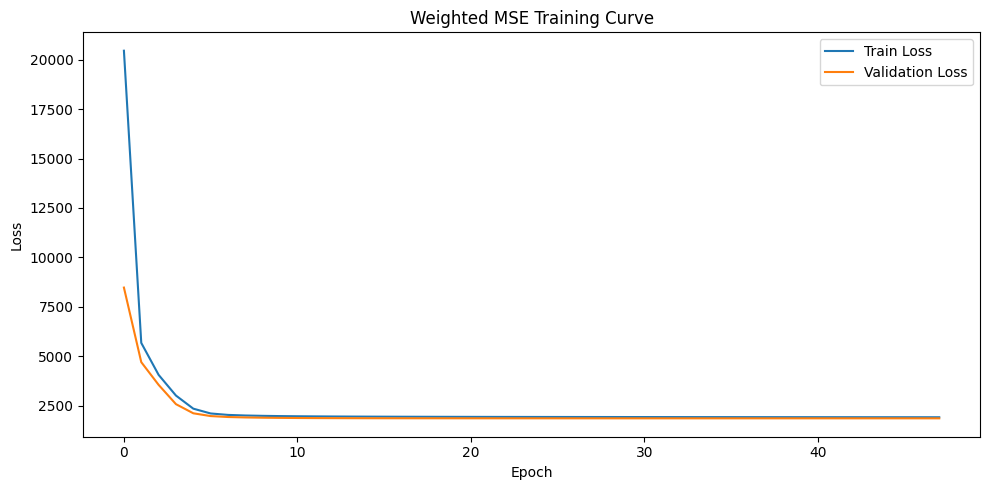

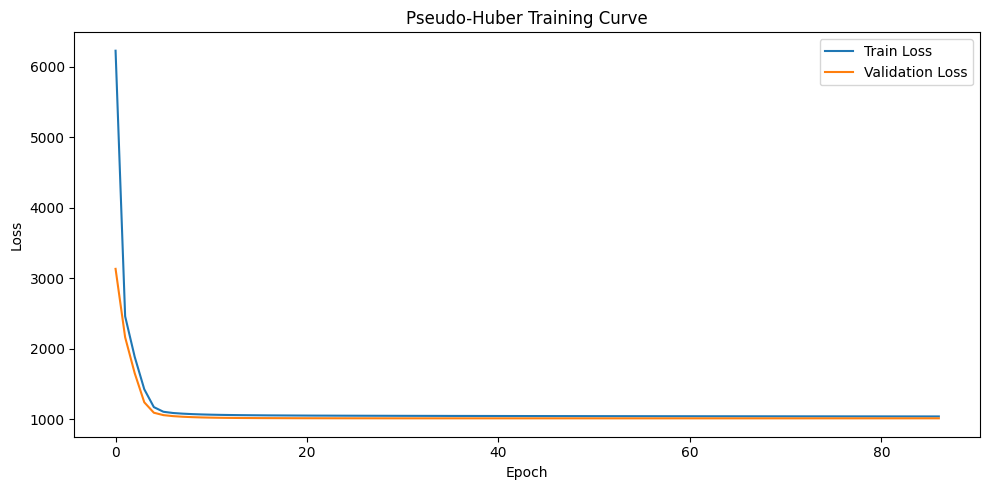

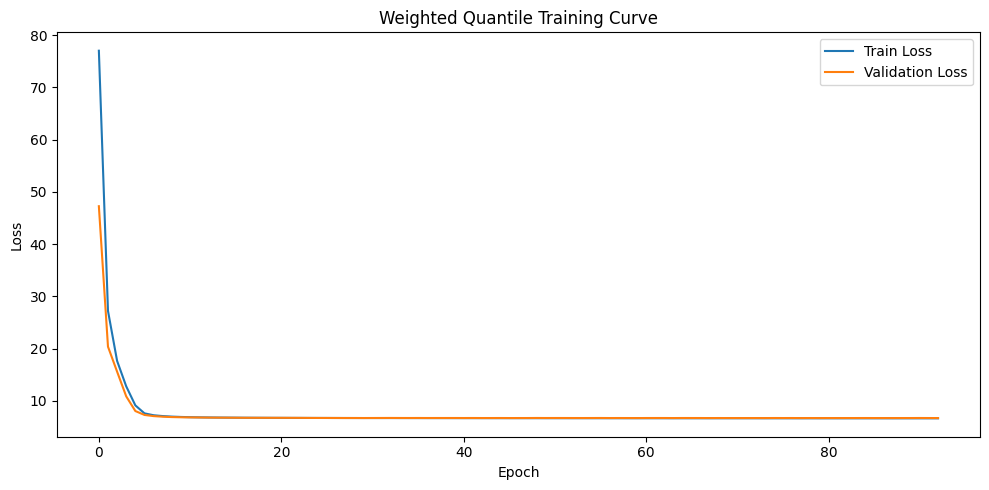

In [868]:
trainingPlotHistory(mseHistory, "Weighted MSE Training Curve")
trainingPlotHistory(huberHistory, "Pseudo-Huber Training Curve")
trainingPlotHistory(quantileHistory, "Weighted Quantile Training Curve")

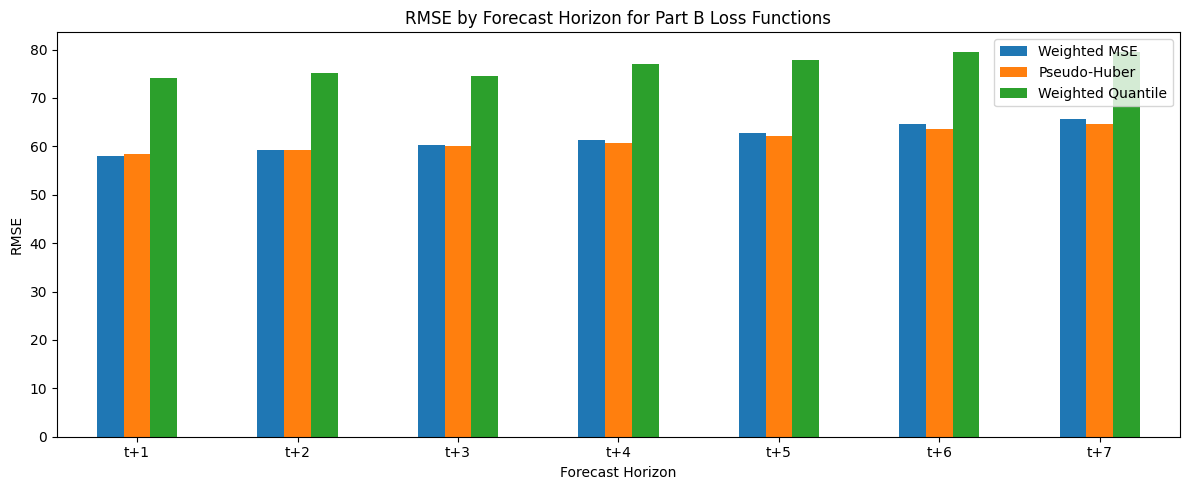

In [869]:
compareRmse = pd.DataFrame({
    "horizon": mseMetrics.loc[mseMetrics["horizon"] != "macro_avg", "horizon"].values,
    "Weighted MSE": mseMetrics.loc[mseMetrics["horizon"] != "macro_avg", "RMSE"].values,
    "Pseudo-Huber": huberMetrics.loc[huberMetrics["horizon"] != "macro_avg", "RMSE"].values,
    "Weighted Quantile": quantileMetrics.loc[quantileMetrics["horizon"] != "macro_avg", "RMSE"].values
})

compareRmse.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE by Forecast Horizon for Part B Loss Functions")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
def comparisonPlotMetric(metric_name):
    dfCompare = pd.DataFrame({
        "horizon": mseMetrics.loc[mseMetrics["horizon"] != "macro_avg", "horizon"].values,
        "Weighted MSE": mseMetrics.loc[mseMetrics["horizon"] != "macro_avg", metric_name].values,
        "Pseudo-Huber": huberMetrics.loc[huberMetrics["horizon"] != "macro_avg", metric_name].values,
        "Weighted Quantile": quantileMetrics.loc[quantileMetrics["horizon"] != "macro_avg", metric_name].values
    })

    dfCompare.plot(x="horizon", kind="bar", figsize=(12, 5))
    plt.title(f"{metric_name} by Forecast Horizon for Part B Loss Functions")
    plt.ylabel(metric_name)
    plt.xlabel("Forecast Horizon")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

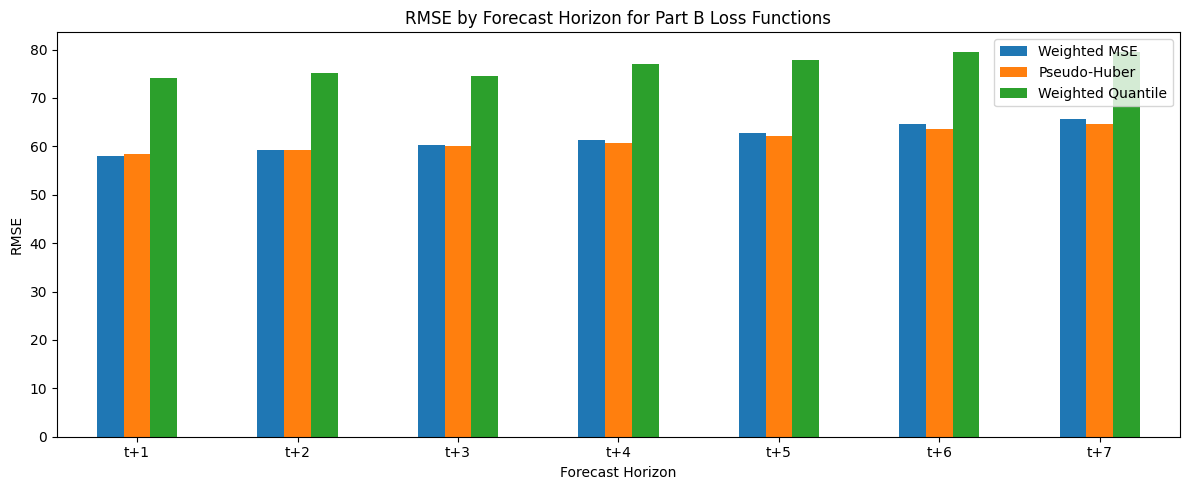

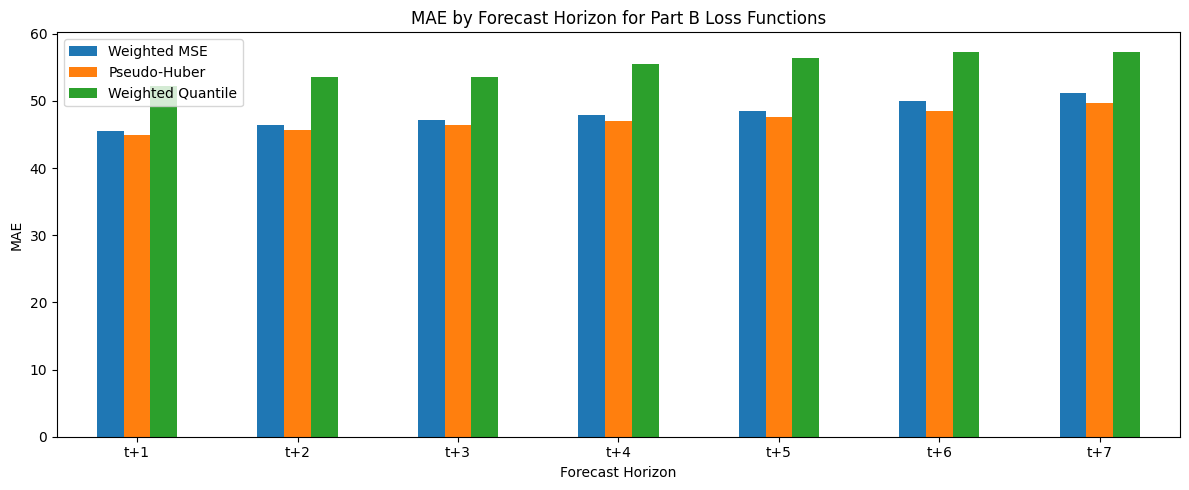

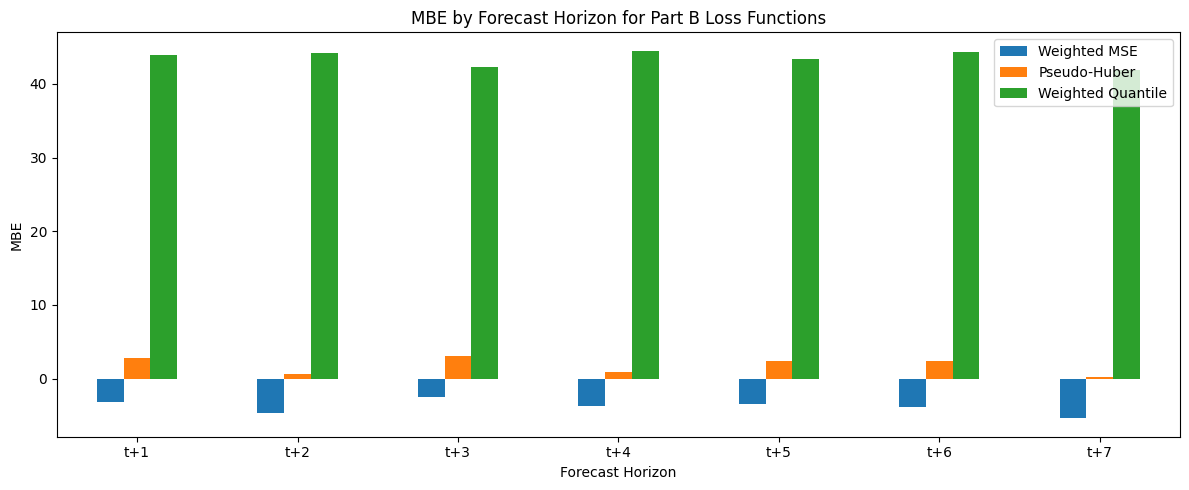

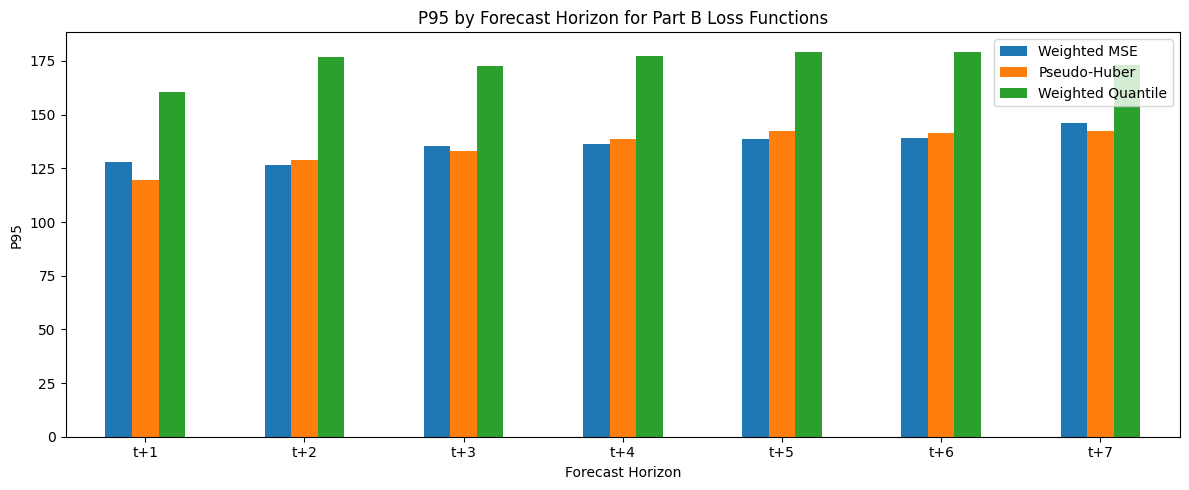

In [871]:
comparisonPlotMetric("RMSE")
comparisonPlotMetric("MAE")
comparisonPlotMetric("MBE")
comparisonPlotMetric("P95")

## Part C — Individual Models and Transfer Learning

- Individual Model Development:
    - Seven Seperate Models
    - Transfer Learning Strategies:
        - Sequential Fine-tuning
        - Feature Extraction
        - Multi-task learning
    - Comparison

In [872]:
y_train_np = y_train.values
y_val_np = y_val.values
y_test_np = y_test.values

print("y_train_np:", y_train_np.shape)
print("y_val_np:  ", y_val_np.shape)
print("y_test_np: ", y_test_np.shape)

y_train_np: (4161, 7)
y_val_np:   (1034, 7)
y_test_np:  (347, 7)


In [873]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [874]:
def singleOutputModelBuild():
    model = keras.Sequential([
        layers.Input(shape=(inputFeatures,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [875]:
resultsIndependent = []
modelsIndependent = []

for horizon in range(7):

    print(f"\nTraining model for horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    model = singleOutputModelBuild()

    stopEarly = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[stopEarly],
        verbose=0
    )

    timeTrained = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    resultsIndependent.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "timeTrained": timeTrained
    })

    modelsIndependent.append(model)

dfIndependent = pd.DataFrame(resultsIndependent)
dfIndependent


Training model for horizon t+1


E0000 00:00:1773985021.814933 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773985028.594938 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type


Training model for horizon t+2

Training model for horizon t+3


E0000 00:00:1773985036.627717 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+4


...


Training model for horizon t+5


E0000 00:00:1773985050.789541 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Training model for horizon t+6

Training model for horizon t+7


E0000 00:00:1773985056.673333 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773985061.703084 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type

,horizon,RMSE,MAE,timeTrained
0,t+1,58.216123,45.047517,6.781873
1,t+2,60.573057,47.166373,3.364214
2,t+3,61.498889,48.096041,4.535376
3,t+4,61.723290,48.623093,8.350692
4,t+5,62.062543,47.928613,5.683178
5,t+6,63.729372,49.286765,4.241765
6,t+7,65.219415,50.638774,6.550228


In [876]:
resultsSequential = []
modelPrevious = None

for horizon in range(7):

    print(f"\nSequential training horizon t+{horizon+1}")

    y_train_h = y_train_np[:, horizon]
    y_val_h = y_val_np[:, horizon]
    y_test_h = y_test_np[:, horizon]

    if modelPrevious is None:
        model = singleOutputModelBuild()
    else:
        model = singleOutputModelBuild()
        model.set_weights(modelPrevious.get_weights())

    stopEarly = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled,
        y_train_h,
        validation_data=(X_val_scaled, y_val_h),
        epochs=100,
        batch_size=32,
        callbacks=[stopEarly],
        verbose=0
    )

    timeTrained = time.time() - start

    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_h, y_pred))
    mae = mean_absolute_error(y_test_h, y_pred)

    resultsSequential.append({
        "horizon": f"t+{horizon+1}",
        "RMSE": rmse,
        "MAE": mae,
        "timeTrained": timeTrained
    })

    modelPrevious = model

dfSequential = pd.DataFrame(resultsSequential)
dfSequential


Sequential training horizon t+1


E0000 00:00:1773985070.526686 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+2


E0000 00:00:1773985076.361932 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+3


...


Sequential training horizon t+4

Sequential training horizon t+5


E0000 00:00:1773985088.354478 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Sequential training horizon t+6

Sequential training horizon t+7


E0000 00:00:1773985093.390374 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,timeTrained
0,t+1,58.125331,45.026374,8.748455
1,t+2,60.148758,46.852421,5.768326
2,t+3,61.630804,47.811798,6.336384
3,t+4,61.656196,48.336681,3.332400
4,t+5,61.627967,47.635529,2.119643
5,t+6,63.360041,48.825964,2.855669
6,t+7,65.064068,50.453425,2.046312


In [877]:
def singleOutputModelFunctionalBuild():
    inputs = keras.Input(shape=(inputFeatures,), name="input_layer")
    x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
    x = layers.Dense(64, activation="relu", name="dense_2")(x)
    outputs = layers.Dense(1, name="output_layer")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [878]:
modelBase = singleOutputModelFunctionalBuild()

modelBase.fit(
    X_train_scaled,
    y_train_np[:, 0],
    validation_data=(X_val_scaled, y_val_np[:, 0]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

In [879]:
inputs = keras.Input(shape=(inputFeatures,), name="input_layer")

x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(1, name="new_output_layer")(x)

modelFeature = keras.Model(inputs=inputs, outputs=outputs)

In [880]:
modelFeature.get_layer("dense_1").set_weights(
    modelBase.get_layer("dense_1").get_weights()
)
modelFeature.get_layer("dense_2").set_weights(
    modelBase.get_layer("dense_2").get_weights()
)

In [881]:
modelFeature.get_layer("dense_1").trainable = False
modelFeature.get_layer("dense_2").trainable = False

In [882]:
start = time.time()

modelFeature.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelFeature.fit(
    X_train_scaled,
    y_train_np[:, 6],
    validation_data=(X_val_scaled, y_val_np[:, 6]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

featureTime = time.time() - start

E0000 00:00:1773985100.021244 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [883]:
yFeaturePredicted = modelFeature.predict(X_test_scaled, verbose=0).flatten()

rsmeFeature = np.sqrt(mean_squared_error(y_test_np[:, 6], yFeaturePredicted))
maeFeature = mean_absolute_error(y_test_np[:, 6], yFeaturePredicted)

dfFeature = pd.DataFrame([{
    "horizon": "t+7",
    "RMSE": rsmeFeature,
    "MAE": maeFeature,
    "timeTrained": featureTime
}])

dfFeature

E0000 00:00:1773985107.692762 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE,timeTrained
0,t+7,68.565432,52.851106,7.682067


In [884]:
def multtaskModelBuild():
    inputs = keras.Input(shape=(inputFeatures,))

    shared = layers.Dense(64, activation="relu")(inputs)
    shared = layers.Dense(64, activation="relu")(shared)

    outputs = []
    for i in range(7):
        head = layers.Dense(32, activation="relu", name=f"head_hidden_{i+1}")(shared)
        out = layers.Dense(1, name=f"h{i+1}")(head)
        outputs.append(out)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [885]:
modelMultitask = multtaskModelBuild()

start = time.time()

modelMultitask.fit(
    X_train_scaled,
    [y_train_np[:, i] for i in range(7)],
    validation_data=(X_val_scaled, [y_val_np[:, i] for i in range(7)]),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)],
    verbose=0
)

multitaskTime = time.time() - start

In [886]:
predictions = modelMultitask.predict(X_test_scaled, verbose=0)

multitaskResults = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], predictions[i].flatten()))
    mae = mean_absolute_error(y_test_np[:, i], predictions[i].flatten())

    multitaskResults.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

dfMultitask = pd.DataFrame(multitaskResults)
dfMultitask

E0000 00:00:1773985114.982016 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.997687,46.721840
1,t+2,59.903039,46.965418
2,t+3,60.667777,47.656661
3,t+4,61.797916,48.608455
4,t+5,63.510054,49.366978
5,t+6,64.993466,50.339069
6,t+7,65.701791,51.150186


In [887]:
dfBaselinePartB = mseMetrics[mseMetrics["horizon"] != "macro_avg"][["horizon", "RMSE", "MAE"]].copy()
dfBaselinePartB["timeTrained"] = np.nan
dfBaselinePartB

,horizon,RMSE,MAE,timeTrained
0,t+1,58.051034,45.466052,NaN
1,t+2,59.319964,46.362272,NaN
2,t+3,60.330482,47.137261,NaN
3,t+4,61.271335,47.935881,NaN
4,t+5,62.734361,48.559518,NaN
5,t+6,64.523911,49.989134,NaN
6,t+7,65.646323,51.197015,NaN


In [888]:
dfComparison = pd.DataFrame({
    "horizon": dfIndependent["horizon"],
    "Part B Multi-output RMSE": dfBaselinePartB["RMSE"].values,
    "Independent RMSE": dfIndependent["RMSE"].values,
    "Sequential TL RMSE": dfSequential["RMSE"].values,
    "Multitask RMSE": dfMultitask["RMSE"].values,
    "Part B Multi-output MAE": dfBaselinePartB["MAE"].values,
    "Independent MAE": dfIndependent["MAE"].values,
    "Sequential TL MAE": dfSequential["MAE"].values,
    "Multitask MAE": dfMultitask["MAE"].values,
    "Independent timeTrained": dfIndependent["timeTrained"].values,
    "Sequential TL timeTrained": dfSequential["timeTrained"].values,
})

dfComparison

,horizon,Part B Multi-output RMSE,Independent RMSE,Sequential TL RMSE,Multitask RMSE,Part B Multi-output MAE,Independent MAE,Sequential TL MAE,Multitask MAE,Independent timeTrained,Sequential TL timeTrained
0,t+1,58.051034,58.216123,58.125331,58.997687,45.466052,45.047517,45.026374,46.721840,6.781873,8.748455
1,t+2,59.319964,60.573057,60.148758,59.903039,46.362272,47.166373,46.852421,46.965418,3.364214,5.768326
2,t+3,60.330482,61.498889,61.630804,60.667777,47.137261,48.096041,47.811798,47.656661,4.535376,6.336384
3,t+4,61.271335,61.723290,61.656196,61.797916,47.935881,48.623093,48.336681,48.608455,8.350692,3.332400
4,t+5,62.734361,62.062543,61.627967,63.510054,48.559518,47.928613,47.635529,49.366978,5.683178,2.119643
5,t+6,64.523911,63.729372,63.360041,64.993466,49.989134,49.286765,48.825964,50.339069,4.241765,2.855669
6,t+7,65.646323,65.219415,65.064068,65.701791,51.197015,50.638774,50.453425,51.150186,6.550228,2.046312


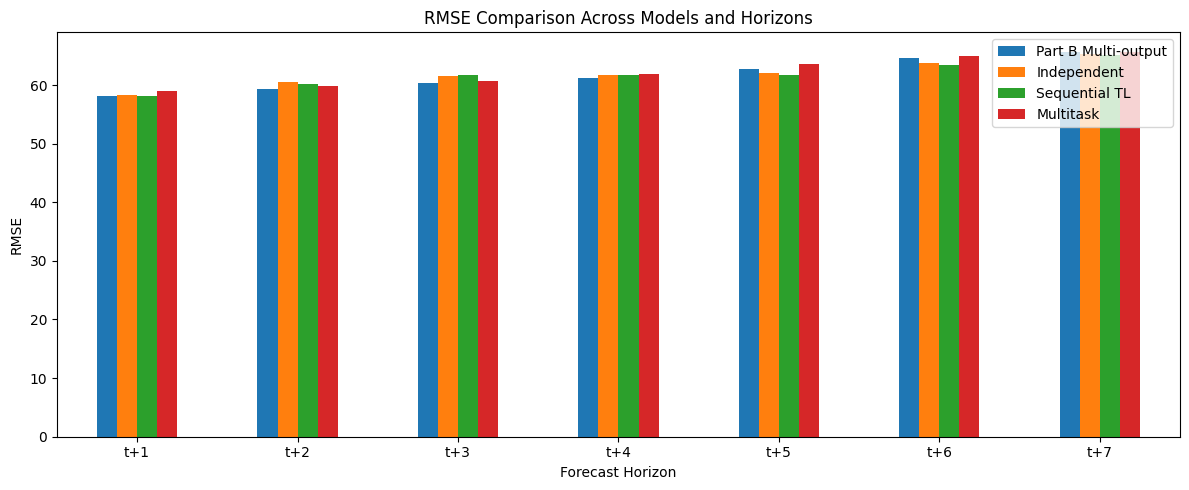

In [889]:
rsmeDfPlot = pd.DataFrame({
    "horizon": dfIndependent["horizon"],
    "Part B Multi-output": dfBaselinePartB["RMSE"].values,
    "Independent": dfIndependent["RMSE"].values,
    "Sequential TL": dfSequential["RMSE"].values,
    "Multitask": dfMultitask["RMSE"].values
})

rsmeDfPlot.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("RMSE Comparison Across Models and Horizons")
plt.ylabel("RMSE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figuresDirectory / "partCRsmeDfPlot.png", dpi=200)
plt.show()

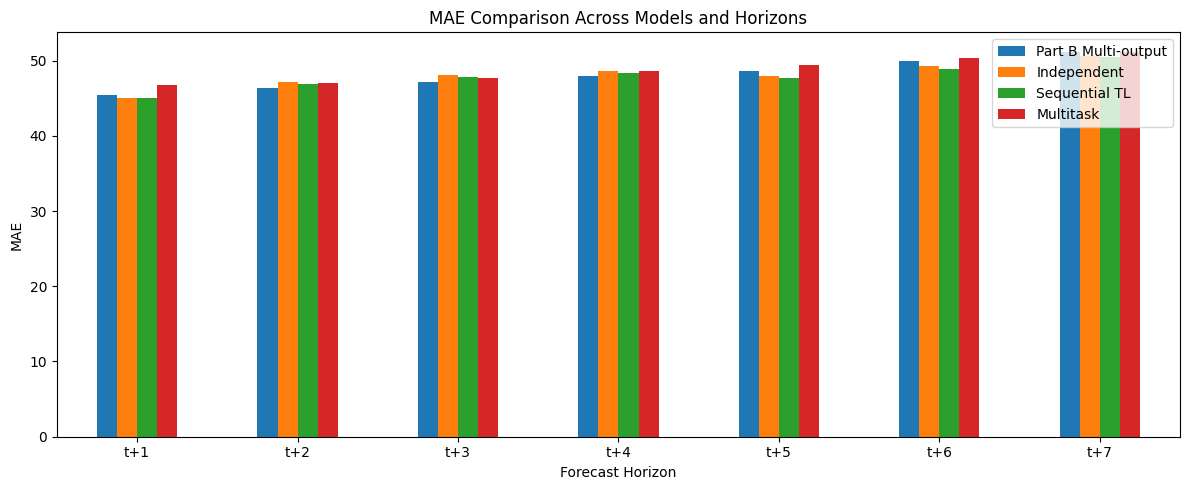

In [890]:
maeDfPlot = pd.DataFrame({
    "horizon": dfIndependent["horizon"],
    "Part B Multi-output": dfBaselinePartB["MAE"].values,
    "Independent": dfIndependent["MAE"].values,
    "Sequential TL": dfSequential["MAE"].values,
    "Multitask": dfMultitask["MAE"].values
})

maeDfPlot.plot(x="horizon", kind="bar", figsize=(12, 5))
plt.title("MAE Comparison Across Models and Horizons")
plt.ylabel("MAE")
plt.xlabel("Forecast Horizon")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figuresDirectory / "partCMaeDfPlot.png", dpi=200)
plt.show()

In [891]:
dfFeature

,horizon,RMSE,MAE,timeTrained
0,t+7,68.565432,52.851106,7.682067


In [892]:
modelFeature.save(modelsDirectory / "featureExtractiont7Model.keras")

## Part D — Advanced Techniques

### 14. Uncertainty Quantification via Monte Carlo Dropout


In [893]:
def mcDropoutModelBuild():

    inputs = keras.Input(shape=(inputFeatures,))

    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [894]:
mcModel = mcDropoutModelBuild()

mcModel.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

E0000 00:00:1773985160.648000 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [895]:
T = 50
mcPredictions = []

for t in range(T):
    predictions = mcModel(X_test_scaled, training=True).numpy()
    mcPredictions.append(predictions)

mcPredictions = np.array(mcPredictions)

In [896]:
mcMean = mcPredictions.mean(axis=0)
mcVar = mcPredictions.var(axis=0)
mcStd = np.sqrt(mcVar)

In [897]:
mcResults = []

for i in range(7):

    rmse = np.sqrt(mean_squared_error(y_test_np[:,i], mcMean[:,i]))
    mae = mean_absolute_error(y_test_np[:,i], mcMean[:,i])

    mcResults.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

dfMc = pd.DataFrame(mcResults)
dfMc

,horizon,RMSE,MAE
0,t+1,58.356344,45.659521
1,t+2,58.893817,46.125510
2,t+3,60.328959,47.423894
3,t+4,61.195142,47.876667
4,t+5,62.646186,48.740285
5,t+6,63.984257,49.667448
6,t+7,65.172708,50.958564


In [898]:
mcMacro = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": dfMc["RMSE"].mean(),
    "MAE": dfMc["MAE"].mean()
}])

dfMc = pd.concat([dfMc, mcMacro], ignore_index=True)
dfMc

,horizon,RMSE,MAE
0,t+1,58.356344,45.659521
1,t+2,58.893817,46.125510
2,t+3,60.328959,47.423894
3,t+4,61.195142,47.876667
4,t+5,62.646186,48.740285
5,t+6,63.984257,49.667448
6,t+7,65.172708,50.958564
7,macro_avg,61.511059,48.064556


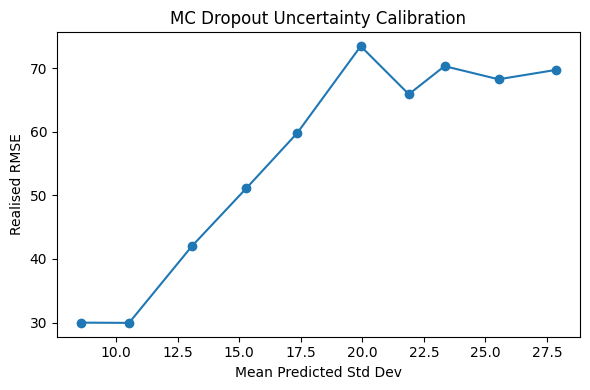

In [899]:
stdPredicted = mcStd.mean(axis=1)

errors = np.sqrt(np.mean((mcMean - y_test_np) ** 2, axis=1))

bins = pd.qcut(stdPredicted, q=10, duplicates="drop")

calibration = pd.DataFrame({
    "std": stdPredicted,
    "rmse": errors,
    "bin": bins
})

dfCalibration = calibration.groupby("bin")[["std", "rmse"]].mean()

plt.figure(figsize=(6, 4))
plt.plot(dfCalibration["std"], dfCalibration["rmse"], marker="o")
plt.xlabel("Mean Predicted Std Dev")
plt.ylabel("Realised RMSE")
plt.title("MC Dropout Uncertainty Calibration")
plt.tight_layout()
plt.savefig(figuresDirectory / "partDMcDropoutPlot.png", dpi=200)
plt.show()

### 15. Temporal Attention Mechanism

In [900]:
featuresLag = X_train_scaled[:, :7]
featuresOther = X_train_scaled[:, 7:]

featuresLag.shape

(4161, 7)

In [901]:
def attentionModelScoresBuild():
    inputs = keras.Input(shape=(inputFeatures,), name="full_input")

    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lagSeq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lagSeq)
    K = layers.Dense(16, name="K_proj")(lagSeq)
    V = layers.Dense(16, name="V_proj")(lagSeq)

    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    contextFlat = layers.Flatten(name="attention_flat")(context)

    concat = layers.Concatenate(name="concat_features")([contextFlat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="modelAttention")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    modelWeights = keras.Model(inputs=inputs, outputs=weights, name="modelAttentionWeights")

    return model, modelWeights

In [902]:
modelAttention, modelAttentionWeights = attentionModelScoresBuild()

modelAttention.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

E0000 00:00:1773985166.233421 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [903]:
attentionPredictions = modelAttention.predict(X_test_scaled, verbose=0)

attentionResults = []

for i in range(7):
    rmse = np.sqrt(mean_squared_error(y_test_np[:, i], attentionPredictions[:, i]))
    mae = mean_absolute_error(y_test_np[:, i], attentionPredictions[:, i])

    attentionResults.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse,
        "MAE": mae
    })

dfAttention = pd.DataFrame(attentionResults)
dfAttention

E0000 00:00:1773985175.621004 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,horizon,RMSE,MAE
0,t+1,58.694281,46.029682
1,t+2,60.029025,47.137889
2,t+3,61.050235,47.821068
3,t+4,62.164031,48.629173
4,t+5,63.343605,49.367336
5,t+6,64.433230,50.261998
6,t+7,65.593008,51.276070


In [904]:
attentionMacro = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": dfAttention["RMSE"].mean(),
    "MAE": dfAttention["MAE"].mean()
}])

dfAttention = pd.concat([dfAttention, attentionMacro], ignore_index=True)
dfAttention

,horizon,RMSE,MAE
0,t+1,58.694281,46.029682
1,t+2,60.029025,47.137889
2,t+3,61.050235,47.821068
3,t+4,62.164031,48.629173
4,t+5,63.343605,49.367336
5,t+6,64.433230,50.261998
6,t+7,65.593008,51.276070
7,macro_avg,62.186773,48.646174


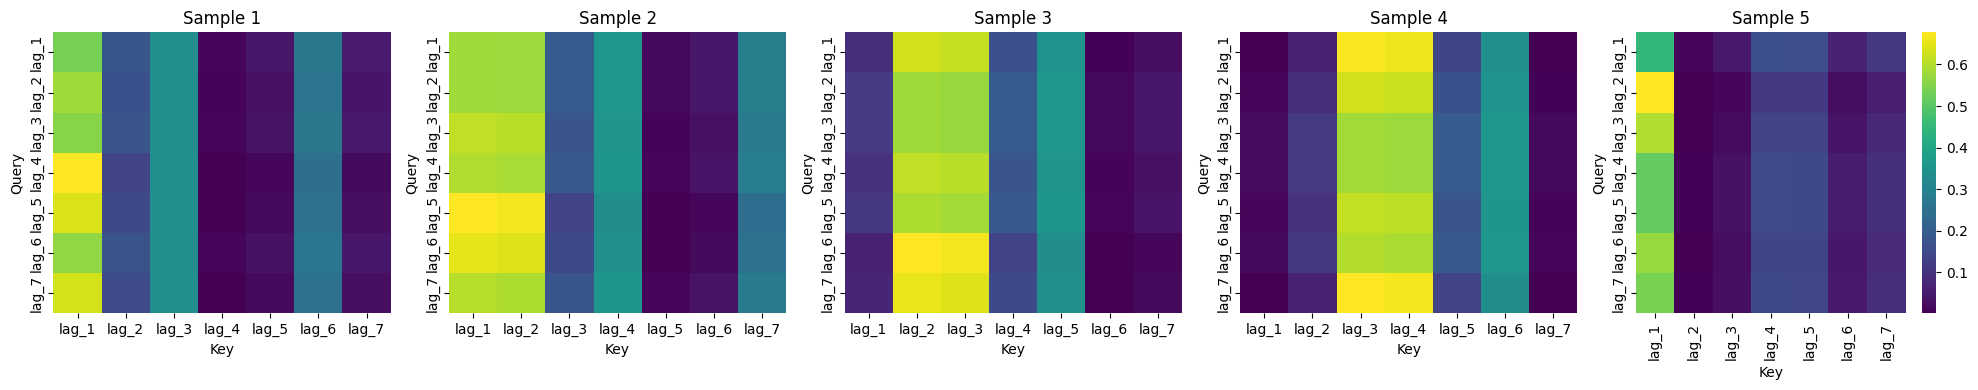

In [905]:
sample = X_test_scaled[:5]
attentionWeights = modelAttentionWeights.predict(sample, verbose=0)   # shape: (5, 7, 7)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    sns.heatmap(
        attentionWeights[i],
        ax=axes[i],
        cmap="viridis",
        cbar=(i == 4),
        xticklabels=[f"lag_{j}" for j in range(1, 8)],
        yticklabels=[f"lag_{j}" for j in range(1, 8)]
    )
    axes[i].set_title(f"Sample {i+1}")
    axes[i].set_xlabel("Key")
    axes[i].set_ylabel("Query")

plt.tight_layout()
plt.show()

### 16. Ablation Study

In [906]:
indexFourier = [0, 1]
indexRolling = [2, 3, 4, 5]
indexLag = [6, 7, 8, 9, 10, 11, 12]

indexAll = list(range(X_train_scaled.shape[1]))

print("All features:", indexAll)
print("Fourier:", indexFourier)
print("Rolling:", indexRolling)
print("Lags:", indexLag)

All features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Fourier: [0, 1]
Rolling: [2, 3, 4, 5]
Lags: [6, 7, 8, 9, 10, 11, 12]


In [907]:
def subsetFeatures(X, keep_idx):
    return X[:, keep_idx]

def multioutputFfnBuild(inputFeatures_local):
    inputs = keras.Input(shape=(inputFeatures_local,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(7)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return model

def macroMetricsEval(y_true, y_pred):
    rmses = []
    maes = []

    for i in range(7):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmses.append(rmse)
        maes.append(mae)

    return np.mean(rmses), np.mean(maes)

In [908]:
def attentionModelScoreBuildDynamic(inputFeatures_local):
    inputs = keras.Input(shape=(inputFeatures_local,), name="full_input")

    lag = layers.Lambda(lambda x: x[:, -7:], name="lag_slice")(inputs)
    other = layers.Lambda(lambda x: x[:, :-7], name="other_slice")(inputs)

    lagSeq = layers.Reshape((7, 1), name="lag_reshape")(lag)

    Q = layers.Dense(16, name="Q_proj")(lagSeq)
    K = layers.Dense(16, name="K_proj")(lagSeq)
    V = layers.Dense(16, name="V_proj")(lagSeq)

    scores = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1], transpose_b=True) / tf.sqrt(tf.cast(tf.shape(x[0])[-1], tf.float32)),
        name="attention_scores"
    )([Q, K])

    weights = layers.Softmax(axis=-1, name="attention_weights")(scores)

    context = layers.Lambda(
        lambda x: tf.matmul(x[0], x[1]),
        name="attention_context"
    )([weights, V])

    contextFlat = layers.Flatten(name="attention_flat")(context)
    concat = layers.Concatenate(name="concat_features")([contextFlat, other])

    x = layers.Dense(64, activation="relu", name="hidden")(concat)
    outputs = layers.Dense(7, name="forecast_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    modelWeights = keras.Model(inputs=inputs, outputs=weights)

    return model, modelWeights

In [909]:
modelAttention, modelAttentionWeights = attentionModelScoreBuildDynamic(X_train_scaled.shape[1])

modelAttention.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

predictionsBaseline = modelAttention.predict(X_test_scaled, verbose=0)
rsmeBaseline, maeBaseline = macroMetricsEval(y_test_np, predictionsBaseline)

print("Baseline Attention Model")
print("Macro RMSE:", rsmeBaseline)
print("Macro MAE:", maeBaseline)

Baseline Attention Model
Macro RMSE: 61.98234083358483
Macro MAE: 48.522103675474575


E0000 00:00:1773985186.213665 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [910]:
noFourier = [i for i in indexAll if i not in indexFourier]

noFourierTrainingX = subsetFeatures(X_train_scaled, noFourier)
noFourierValidationX = subsetFeatures(X_val_scaled, noFourier)
noFourierTestX = subsetFeatures(X_test_scaled, noFourier)

noFourierModel, _ = attentionModelScoreBuildDynamic(noFourierTrainingX.shape[1])

noFourierModel.fit(
    noFourierTrainingX,
    y_train_np,
    validation_data=(noFourierValidationX, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

noFourierpredictions = noFourierModel.predict(noFourierTestX, verbose=0)
noFourierRsme, noFourierMae = macroMetricsEval(y_test_np, noFourierpredictions)

print("No Fourier - Macro RMSE:", noFourierRsme)
print("No Fourier - Macro MAE:", noFourierMae)

No Fourier - Macro RMSE: 70.31091874994753
No Fourier - Macro MAE: 53.89684122545019


E0000 00:00:1773985196.169089 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [911]:
noRolling = [i for i in indexAll if i not in indexRolling]

noRollingTrainX = subsetFeatures(X_train_scaled, noRolling)
noRollingValidationX = subsetFeatures(X_val_scaled, noRolling)
noRollingTestX = subsetFeatures(X_test_scaled, noRolling)

noRollingModel, _ = attentionModelScoreBuildDynamic(noRollingTrainX.shape[1])

noRollingModel.fit(
    noRollingTrainX,
    y_train_np,
    validation_data=(noRollingValidationX, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

noRollingPredictions = noRollingModel.predict(noRollingTestX, verbose=0)
noRollingRsme, noRollingMae = macroMetricsEval(y_test_np, noRollingPredictions)

print("No Rolling - Macro RMSE:", noRollingRsme)
print("No Rolling - Macro MAE:", noRollingMae)

No Rolling - Macro RMSE: 63.39157269397193
No Rolling - Macro MAE: 49.38309062466114


E0000 00:00:1773985205.924504 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [912]:
noLags = [i for i in indexAll if i not in indexLag]

noLagsTrainX = subsetFeatures(X_train_scaled, noLags)
noLagsValidationX = subsetFeatures(X_val_scaled, noLags)
noLagsTestX = subsetFeatures(X_test_scaled, noLags)

noLagsModel = multioutputFfnBuild(noLagsTrainX.shape[1])

noLagsModel.fit(
    noLagsTrainX,
    y_train_np,
    validation_data=(noLagsValidationX, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

noLagsPredictions = noLagsModel.predict(noLagsTestX, verbose=0)
noLagsRsme, noLagsMae = macroMetricsEval(y_test_np, noLagsPredictions)

print("No Lags - Macro RMSE:", noLagsRsme)
print("No Lags - Macro MAE:", noLagsMae)

No Lags - Macro RMSE: 61.65734662516468
No Lags - Macro MAE: 48.09117778809844


In [913]:
noAttentionModel = multioutputFfnBuild(X_train_scaled.shape[1])

noAttentionModel.fit(
    X_train_scaled,
    y_train_np,
    validation_data=(X_val_scaled, y_val_np),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

noAttentionPredictions = noAttentionModel.predict(X_test_scaled, verbose=0)
noAttentionRsme, noAttentionMae = macroMetricsEval(y_test_np, noAttentionPredictions)

print("No Attention - Macro RMSE:", noAttentionRsme)
print("No Attention - Macro MAE:", noAttentionMae)

No Attention - Macro RMSE: 61.48596897553945
No Attention - Macro MAE: 47.97574958288451


E0000 00:00:1773985214.632632 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [914]:
dfAblation = pd.DataFrame([
    {"model": "Full Attention Model", "RMSE": rsmeBaseline, "MAE": maeBaseline},
    {"model": "Remove Fourier", "RMSE": noFourierRsme, "MAE": noFourierMae},
    {"model": "Remove Rolling", "RMSE": noRollingRsme, "MAE": noRollingMae},
    {"model": "Remove Lags", "RMSE": noLagsRsme, "MAE": noLagsMae},
    {"model": "Remove Attention", "RMSE": noAttentionRsme, "MAE": noAttentionMae},
])

dfAblation["RMSE_degradation"] = dfAblation["RMSE"] - rsmeBaseline
dfAblation["MAE_degradation"] = dfAblation["MAE"] - maeBaseline

dfAblation

,model,RMSE,MAE,RMSE_degradation,MAE_degradation
0,Full Attention Model,61.982341,48.522104,0.000000,0.000000
1,Remove Fourier,70.310919,53.896841,8.328578,5.374738
2,Remove Rolling,63.391573,49.383091,1.409232,0.860987
3,Remove Lags,61.657347,48.091178,-0.324994,-0.430926
4,Remove Attention,61.485969,47.975750,-0.496372,-0.546354


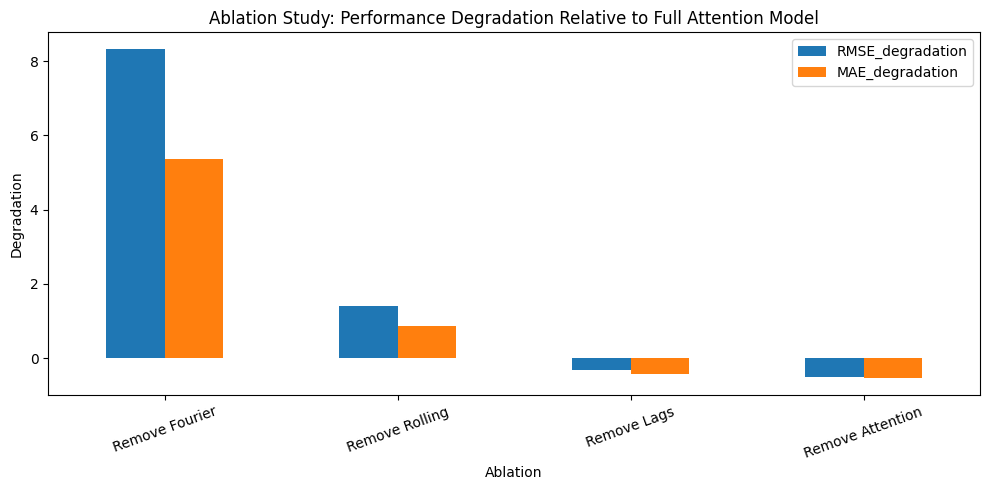

In [915]:
dfPlot = dfAblation[dfAblation["model"] != "Full Attention Model"].copy()

dfPlot.plot(
    x="model",
    y=["RMSE_degradation", "MAE_degradation"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Performance Degradation Relative to Full Attention Model")
plt.ylabel("Degradation")
plt.xlabel("Ablation")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

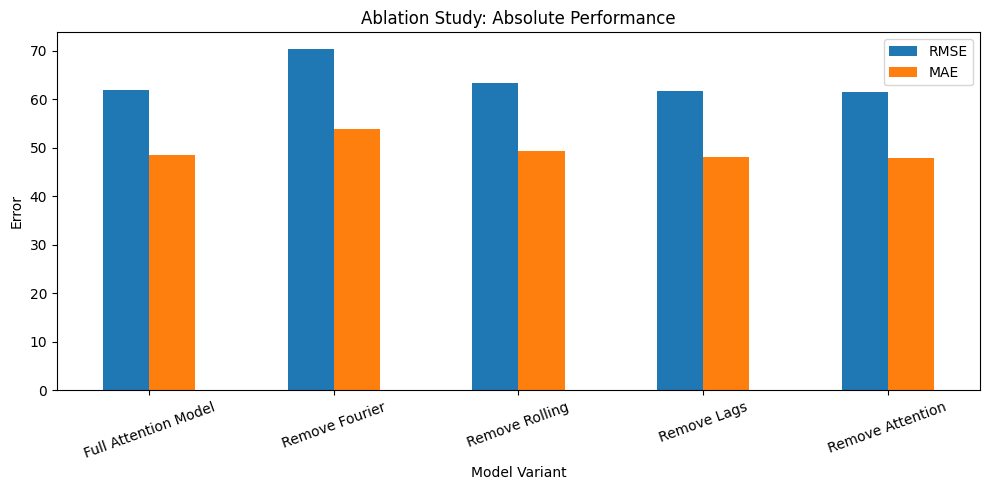

In [916]:
dfAblation.plot(
    x="model",
    y=["RMSE", "MAE"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ablation Study: Absolute Performance")
plt.ylabel("Error")
plt.xlabel("Model Variant")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Part E: Statistical Analysis and Discussion

In [917]:
from scipy.stats import ttest_rel, t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [918]:
modelPartB = mseModel

In [919]:
multiPrediction = modelPartB.predict(X_test_scaled, verbose=0)

individualPrediction = np.column_stack([
    modelsIndependent[i].predict(X_test_scaled, verbose=0).flatten()
    for i in range(7)
])

rawMultitaskPrediction = modelMultitask.predict(X_test_scaled, verbose=0)
multitaskPrediction = np.column_stack([p.flatten() for p in rawMultitaskPrediction])

attentionPrediction = modelAttention.predict(X_test_scaled, verbose=0)

print("Shapes:")
print("y_test_np      :", y_test_np.shape)
print("multiPrediction     :", multiPrediction.shape)
print("individualPrediction:", individualPrediction.shape)
print("multitaskPrediction :", multitaskPrediction.shape)
print("attentionPrediction :", attentionPrediction.shape)

E0000 00:00:1773985222.826886 10312125 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Shapes:
y_test_np      : (347, 7)
multiPrediction     : (347, 7)
individualPrediction: (347, 7)
multitaskPrediction : (347, 7)
attentionPrediction : (347, 7)


In [920]:
maeMulti = np.mean(np.abs(y_test_np - multiPrediction), axis=1)
maeIndividual = np.mean(np.abs(y_test_np - individualPrediction), axis=1)
maeAttention = np.mean(np.abs(y_test_np - attentionPrediction), axis=1)
maeMultitask = np.mean(np.abs(y_test_np - multitaskPrediction), axis=1)

print("Daily MAE vector lengths:")
print(len(maeMulti), len(maeIndividual), len(maeAttention), len(maeMultitask))

Daily MAE vector lengths:
347 347 347 347


In [921]:
comparisons = {
    "multi-output vs individual": (maeMulti, maeIndividual),
    "attention vs multi-output": (maeAttention, maeMulti),
    "multi-output vs multi-task": (maeMulti, maeMultitask),
}

ttestResults = []

for name, (a, b) in comparisons.items():
    diff = a - b
    n = len(diff)

    tStatistics, pValue = ttest_rel(a, b)

    meanDifference = np.mean(diff)
    sdDifference = np.std(diff, ddof=1)
    seDifference = sdDifference / np.sqrt(n)
    tCritical = t.ppf(0.975, df=n - 1)

    ciLow = meanDifference - tCritical * seDifference
    ciHigh = meanDifference + tCritical * seDifference

    ttestResults.append({
        "comparison": name,
        "meanDifference": meanDifference,
        "tStatistic": tStatistics,
        "pValue": pValue,
        "ci_95_low": ciLow,
        "ci_95_high": ciHigh
    })

dTtest = pd.DataFrame(ttestResults)
dTtest

,comparison,meanDifference,tStatistic,pValue,ci_95_low,ci_95_high
0,multi-output vs individual,-0.020006,-0.116483,0.907337,-0.357815,0.317803
1,attention vs multi-output,0.429656,1.810425,0.071097,-0.037122,0.896434
2,multi-output vs multi-task,-0.594496,-4.742033,0.000003,-0.841074,-0.347918


In [922]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def errorStatisticsGrouped(df, group_col, yTrueCols, yPredictedCols):
    rows = []

    for group_name, g in df.groupby(group_col):
        y_true_g = g[yTrueCols].values
        y_pred_g = g[yPredictedCols].values

        rsmeDaily = np.sqrt(np.mean((y_true_g - y_pred_g) ** 2, axis=1))
        maeDaily = np.mean(np.abs(y_true_g - y_pred_g), axis=1)

        rows.append({
            group_col: group_name,
            "RMSE": rsmeDaily.mean(),
            "MAE": maeDaily.mean()
        })

    return pd.DataFrame(rows)

def groupedBarPlot(df, category_col, title):
    dfPlot = df.set_index(category_col)[["RMSE", "MAE"]]
    dfPlot.plot(kind="bar", figsize=(8, 4))
    plt.title(title)
    plt.ylabel("Error")
    plt.xlabel(category_col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [923]:
dfAnalysis = test_df[["date", "solar_t"]].copy().reset_index(drop=True)

for i in range(7):
    dfAnalysis[f"y_true_t+{i+1}"] = y_test_np[:, i]
    dfAnalysis[f"y_pred_t+{i+1}"] = multiPrediction[:, i]

dfAnalysis["rsmeDailyAverage7"] = np.sqrt(np.mean((y_test_np - multiPrediction) ** 2, axis=1))
dfAnalysis["maeDailyAverage7"] = np.mean(np.abs(y_test_np - multiPrediction), axis=1)

dfAnalysis.head()

,date,solar_t,y_true_t+1,y_pred_t+1,y_true_t+2,y_pred_t+2,y_true_t+3,y_pred_t+3,y_true_t+4,y_pred_t+4,y_true_t+5,y_pred_t+5,y_true_t+6,y_pred_t+6,y_true_t+7,y_pred_t+7,rsmeDailyAverage7,maeDailyAverage7
0,2011-01-26,137.692525,100.465418,113.187744,60.668584,113.043877,166.628151,116.589394,82.132143,116.970421,81.416851,118.416916,113.866370,119.303185,148.104861,120.504372,35.421871,31.430289
1,2011-01-30,100.465418,60.668584,118.474686,166.628151,119.345367,82.132143,122.166565,81.416851,122.523613,113.866370,123.416931,148.104861,124.847527,108.520950,126.410553,37.458325,33.846796
2,2011-01-31,60.668584,166.628151,122.061684,82.132143,122.484863,81.416851,125.162605,113.866370,124.854996,148.104861,126.331818,108.520950,127.945374,180.943450,129.534637,36.140979,33.179978
3,2011-02-02,166.628151,82.132143,127.908638,81.416851,128.316772,113.866370,130.430664,148.104861,129.875076,108.520950,131.402481,180.943450,133.480438,187.222140,134.492249,38.653284,35.792133
4,2011-02-03,82.132143,81.416851,126.710960,113.866370,125.481247,148.104861,129.044174,108.520950,129.310745,180.943450,131.437622,187.222140,132.196838,185.396055,133.306015,39.953491,36.197234


In [924]:
months = pd.to_datetime(dfAnalysis["date"]).dt.month

def monthToSeason(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

dfAnalysis["season"] = months.map(monthToSeason)

yTrueCols = [f"y_true_t+{i+1}" for i in range(7)]
yPredictedCols = [f"y_pred_t+{i+1}" for i in range(7)]

seasonStats = errorStatisticsGrouped(dfAnalysis, "season", yTrueCols, yPredictedCols)
seasonStats

,season,RMSE,MAE
0,autumn,51.987222,43.990371
1,spring,80.083929,67.598802
2,summer,56.892774,48.835751
3,winter,41.118879,36.499000


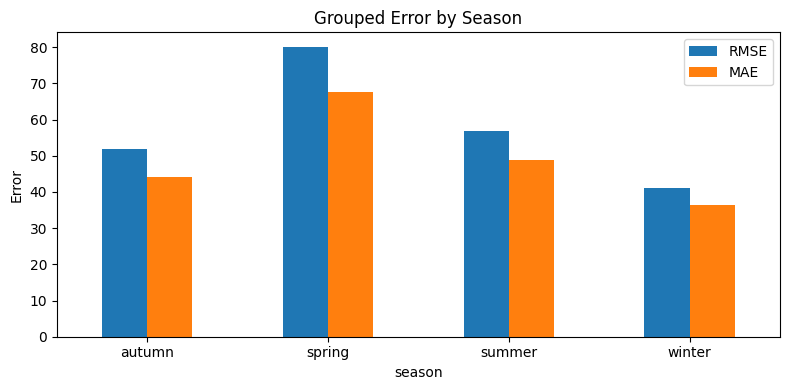

In [925]:
groupedBarPlot(seasonStats, "season", "Grouped Error by Season")

In [926]:
shortTrue = y_test_np[:, :3]
shortPredicted = multiPrediction[:, :3]

longTrue = y_test_np[:, 3:]
longPredicted = multiPrediction[:, 3:]

dfHorizonGroup = pd.DataFrame([
    {
        "horizonGroup": "short-term",
        "RMSE": rmse(shortTrue, shortPredicted),
        "MAE": mae(shortTrue, shortPredicted)
    },
    {
        "horizonGroup": "long-term",
        "RMSE": rmse(longTrue, longPredicted),
        "MAE": mae(longTrue, longPredicted)
    }
])

dfHorizonGroup

,horizonGroup,RMSE,MAE
0,short-term,59.241167,46.321862
1,long-term,63.566012,49.420387


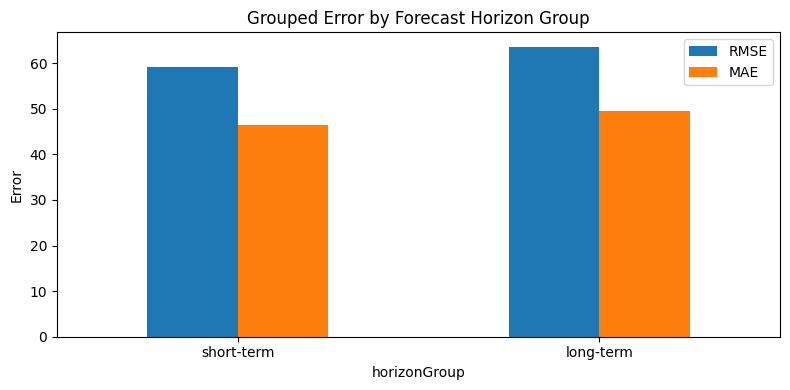

In [927]:
groupedBarPlot(dfHorizonGroup, "horizonGroup", "Grouped Error by Forecast Horizon Group")

In [928]:
p25 = np.percentile(dfTrained["solar_t"], 25)
p75 = np.percentile(dfTrained["solar_t"], 75)

def classifyWeather(v):
    if v > p75:
        return "clear"
    elif v < p25:
        return "cloudy"
    else:
        return "mixed"

dfAnalysis["weatherCondition"] = dfAnalysis["solar_t"].apply(classifyWeather)

weatherStatistics = errorStatisticsGrouped(dfAnalysis, "weatherCondition", yTrueCols, yPredictedCols)
weatherStatistics

,weatherCondition,RMSE,MAE
0,clear,71.518811,61.212493
1,cloudy,39.740205,34.689512
2,mixed,57.817102,49.219880


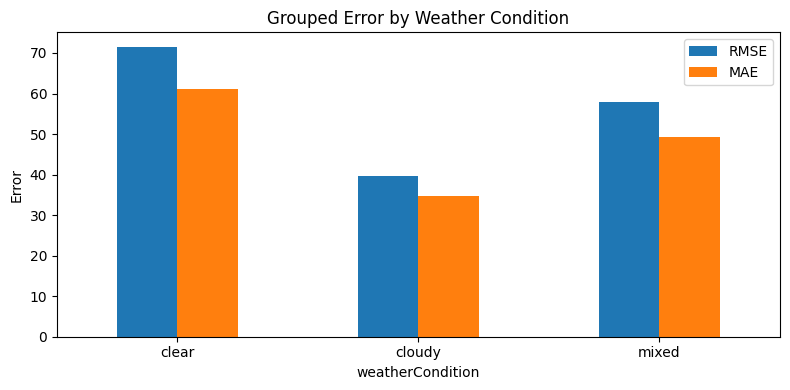

In [929]:
groupedBarPlot(weatherStatistics, "weatherCondition", "Grouped Error by Weather Condition")

In [930]:
p33 = np.percentile(dfTrained["solar_t"], 33.3333)
p67 = np.percentile(dfTrained["solar_t"], 66.6667)

def classifyMagnitude(v):
    if v < p33:
        return "low"
    elif v < p67:
        return "medium"
    else:
        return "high"

dfAnalysis["radiationMagnitude"] = dfAnalysis["solar_t"].apply(classifyMagnitude)

magnitudeStatistics = errorStatisticsGrouped(dfAnalysis, "radiationMagnitude", yTrueCols, yPredictedCols)
magnitudeStatistics

,radiationMagnitude,RMSE,MAE
0,high,71.237022,60.634162
1,low,39.953195,34.634083
2,medium,58.445600,49.984034


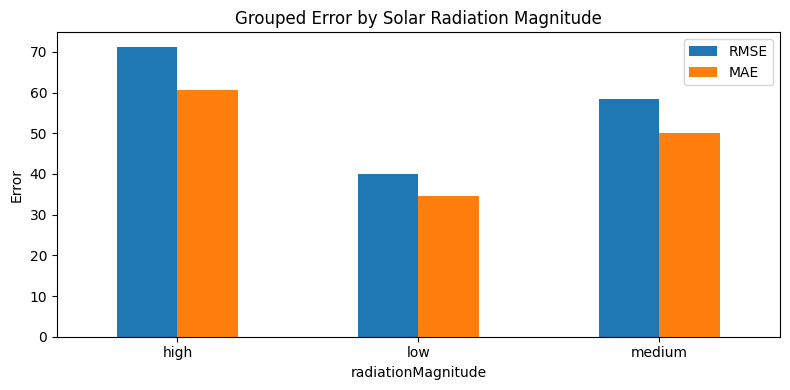

In [931]:
groupedBarPlot(magnitudeStatistics, "radiationMagnitude", "Grouped Error by Solar Radiation Magnitude")

In [932]:
dfAnalysis[[
    "date", "solar_t", "season", "weatherCondition", "radiationMagnitude",
    "rsmeDailyAverage7", "maeDailyAverage7"
]].head()

,date,solar_t,season,weatherCondition,radiationMagnitude,rsmeDailyAverage7,maeDailyAverage7
0,2011-01-26,137.692525,winter,mixed,medium,35.421871,31.430289
1,2011-01-30,100.465418,winter,cloudy,low,37.458325,33.846796
2,2011-01-31,60.668584,winter,cloudy,low,36.140979,33.179978
3,2011-02-02,166.628151,winter,mixed,medium,38.653284,35.792133
4,2011-02-03,82.132143,winter,cloudy,low,39.953491,36.197234


## Code to save models

In [933]:
from tensorflow import keras
import joblib
from pathlib import Path

modelsDirectory = Path("models")
scalersDirectory = Path("scalers")

modelsDirectory.mkdir(exist_ok=True)
scalersDirectory.mkdir(exist_ok=True)

# Part B
mseModel.save(modelsDirectory / "mseModelPartB.keras")

# Part C
for i, model in enumerate(modelsIndependent, start=1):
    model.save(modelsDirectory / f"independentModel_t{i}.keras")

# Part C
modelPrevious.save(modelsDirectory / "sequentialFinalModel.keras")

# Part C
modelMultitask.save(modelsDirectory / "modelMultitask.keras")

# Part D
mcModel.save(modelsDirectory / "mcDropoutModel.keras")
modelAttention.save(modelsDirectory / "modelAttention.keras")

# scaler
joblib.dump(scaler, scalersDirectory / "featureScaler.pkl")

print("Scaler and Models saved.")

Scaler and Models saved.


## Evaluation Cell

In [ ]:
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error

baseDirectory = Path.cwd()
# hiddenDirectory = baseDirectory / "datasets" TEST TO SEE IF EVALUATION CELL IS WORKING
hiddenDirectory = baseDirectory / "hidden_data"
modelsDirectory = baseDirectory / "models"
scalerPath = baseDirectory / "scalers" / "featureScaler.pkl"

def mseWeighted(y_true, y_pred):
    weights = tf.constant([1 / np.sqrt(k) for k in range(1, 8)], dtype=tf.float32)
    return tf.reduce_mean(weights * tf.square(y_true - y_pred))

filesHidden = sorted(glob.glob(str(hiddenDirectory / "daily_solar_*.csv")))
print("Hidden files:", filesHidden)

if len(filesHidden) == 0:
    raise FileNotFoundError(f"No CSV files in {hiddenDirectory}")

dfsHidden = []
for file in filesHidden:
    df = pd.read_csv(file)
    dfsHidden.append(df)

rawHidden = pd.concat(dfsHidden, ignore_index=True)
rawHidden["date"] = pd.to_datetime(rawHidden["date"])
rawHidden = rawHidden.sort_values("date").reset_index(drop=True)

print("Hidden raw shape:", rawHidden.shape)
rawHidden.head()

cleanHidden = rawHidden[rawHidden["bad_quality"] == 0].copy()
cleanHidden = cleanHidden.sort_values("date").reset_index(drop=True)

cleanHidden["day_of_year"] = cleanHidden["date"].dt.dayofyear
cleanHidden["is_leap_year"] = cleanHidden["date"].dt.is_leap_year.astype(int)
cleanHidden["days_in_year"] = np.where(cleanHidden["is_leap_year"] == 1, 366, 365)

cleanHidden["day_sin"] = np.sin(2 * np.pi * cleanHidden["day_of_year"] / cleanHidden["days_in_year"])
cleanHidden["day_cos"] = np.cos(2 * np.pi * cleanHidden["day_of_year"] / cleanHidden["days_in_year"])

cleanHidden["solar_mean_7d"] = cleanHidden["solar_t"].rolling(window=7, min_periods=7).mean()
cleanHidden["solar_std_7d"]  = cleanHidden["solar_t"].rolling(window=7, min_periods=7).std(ddof=1)
cleanHidden["solar_min_7d"]  = cleanHidden["solar_t"].rolling(window=7, min_periods=7).min()
cleanHidden["solar_max_7d"]  = cleanHidden["solar_t"].rolling(window=7, min_periods=7).max()

for k in range(1, 8):
    cleanHidden[f"lag_{k}"] = cleanHidden["solar_t"].shift(k)

for k in range(1, 8):
    cleanHidden[f"target_t_plus_{k}"] = cleanHidden["solar_t"].shift(-k)

columnsFeatured = [
    "day_sin",
    "day_cos",
    "solar_mean_7d",
    "solar_std_7d",
    "solar_min_7d",
    "solar_max_7d",
] + [f"lag_{k}" for k in range(1, 8)]

columnTargets = [f"target_t_plus_{k}" for k in range(1, 8)]

dfModelHidden = cleanHidden.dropna(subset=columnsFeatured + columnTargets).copy().reset_index(drop=True)

print("Hidden processed shape:", dfModelHidden.shape)
dfModelHidden.head()

hiddenX = dfModelHidden[columnsFeatured].copy()
hiddenY = dfModelHidden[columnTargets].copy().values

loadScaler = joblib.load(scalerPath)
scaledHiddenX = loadScaler.transform(hiddenX)

print("scaledHiddenX:", scaledHiddenX.shape)
print("hiddenY:", hiddenY.shape)

modelPartB = keras.models.load_model(
    modelsDirectory / "mseModelPartB.keras",
    custom_objects={"weighted_mse": mseWeighted},
    compile=False
)

loadModelsIndependent = [
    keras.models.load_model(modelsDirectory / f"independentModel_t{i}.keras", compile=False)
    for i in range(1, 8)
]

loadSequentialModel = keras.models.load_model(
    modelsDirectory / "sequentialFinalModel.keras",
    compile=False
)

loadMultitaskModel = keras.models.load_model(
    modelsDirectory / "modelMultitask.keras",
    compile=False
)

loadMcModel = keras.models.load_model(
    modelsDirectory / "mcDropoutModel.keras",
    compile=False
)

loadAttentionModel = modelAttention

modelFeaturePath = modelsDirectory / "feature_extraction_t7_model.keras"
if modelFeaturePath.exists():
    loadModelFeature = keras.models.load_model(modelFeaturePath, compile=False)
    print("Feature extraction model loaded.")
else:
    loadModelFeature = None
    print("Feature extraction model not found, skipping.")

print("All required models are ready.")

hiddenPredictions = modelPartB.predict(scaledHiddenX, verbose=0)

hiddenResults = []

for i in range(7):
    rmse_i = np.sqrt(mean_squared_error(hiddenY[:, i], hiddenPredictions[:, i]))
    mae_i = mean_absolute_error(hiddenY[:, i], hiddenPredictions[:, i])

    hiddenResults.append({
        "horizon": f"t+{i+1}",
        "RMSE": rmse_i,
        "MAE": mae_i
    })

dfMetricsHidden = pd.DataFrame(hiddenResults)

rowMacro = pd.DataFrame([{
    "horizon": "macro_avg",
    "RMSE": dfMetricsHidden["RMSE"].mean(),
    "MAE": dfMetricsHidden["MAE"].mean()
}])

dfMetricsHidden = pd.concat([dfMetricsHidden, rowMacro], ignore_index=True)
dfMetricsHidden

plt.figure(figsize=(12, 4))
plt.plot(hiddenY[:100, 0], label="Observed t+1")
plt.plot(hiddenPredictions[:100, 0], label="Predicted t+1")
plt.title("Hidden Test Set: Predictions vs Observations (t+1)")
plt.xlabel("Sample Index")
plt.ylabel("Solar Radiation")
plt.legend()
plt.tight_layout()
plt.show()

hiddenErrors = (hiddenPredictions - hiddenY).flatten()

plt.figure(figsize=(8, 4))
plt.hist(hiddenErrors, bins=40, edgecolor="black")
plt.title("Hidden Test: Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

hiddenAttentionPrediction = loadAttentionModel.predict(scaledHiddenX, verbose=0)

dfModelsCompare = []

for name, pred in {
    "PartB MultiOutput": hiddenPredictions,
    "Attention": hiddenAttentionPrediction
}.items():
    rmses = []
    maes = []

    for i in range(7):
        rmses.append(np.sqrt(mean_squared_error(hiddenY[:, i], pred[:, i])))
        maes.append(mean_absolute_error(hiddenY[:, i], pred[:, i]))

    dfModelsCompare.append({
        "model": name,
        "macro_RMSE": np.mean(rmses),
        "macro_MAE": np.mean(maes)
    })

dfModelsCompare = pd.DataFrame(dfModelsCompare)
dfModelsCompare